# 2.2 Full EIP-7999 equilibrium with two-sided BAL demand

This notebook evaluates the aggregate two-sided BAL specification as a separate alternative to
notebook 2.0's one-sided incremental-surcharge model. Notebook 2.0 remains the executable
surcharge specification.

Static transaction data retains its independently estimated own-price elasticity
$\epsilon_{\mathrm{data}}$. Runtime BAL receives a distinct data-price elasticity
$\gamma_{\mathrm{BAL}}$:

$$
g_{\mathrm{BAL}}(b_{\mathrm{data}})
=\widetilde B(\lambda)
\left(\frac{b_{\mathrm{data}}}{b_{\mathrm{data}}^0}\right)^{-\gamma_{\mathrm{BAL}}}.
$$

The curve is two-sided around the cost-equivalent reference fee $b_{\mathrm{data}}^0$. A lower
data fee expands modeled activity among BAL-carrying transactions; a higher fee contracts it.
This differs
from $\Psi_{\mathrm{BAL}}$, which treats BAL pricing as a one-sided surcharge on historical
BAL-carrying transactions.

The analysis sweeps $\lambda\in\{0,0.5,1\}$ and
$\gamma_{\mathrm{BAL}}\in\{0,0.01,0.02,0.03,0.04\}$ over the full capacity grid and the four
empirically paired capacity scenarios. All four elasticity windows are also evaluated.


In [1]:
from itertools import product
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import brentq

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from basefee.eip7999_normalized import (
    ResourceFeeConfig,
    compute_base_fee,
    excess_gas_for_base_fee,
)

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 18,
})
plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.6f}".format

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
DATE_LABEL = "2026-02-01_2026-06-01"
GWEI = 1e9
MIN_BASE_FEE_WEI = 1
RESOURCES = ["execution", "data", "state"]

ACCOUNTING_PANEL_CSV = DATA_DIR / f"daily_accounting_panel_calibrated_with_bal_{DATE_LABEL}.csv"
CURRENT_DATA_CSV = DATA_DIR / f"daily_current_data_gas_xatu_{DATE_LABEL}.csv"
EXECUTION_REPRICING_DAILY_CSV = DATA_DIR / f"execution_repricing_daily_{DATE_LABEL}.csv"
BAL_RUNTIME_CARD_CSV = DATA_DIR / f"bal_runtime_8279_parameter_card_{DATE_LABEL}.csv"
ELASTICITY_CSV = DATA_DIR / "three_way_isoelastic_calibration_2025.csv"
CURRENT_20_RESULTS_CSV = DATA_DIR / f"full_7999_equilibrium_results_{DATE_LABEL}.csv"
CURRENT_20_BAL_SENSITIVITY_CSV = DATA_DIR / f"full_7999_bal_lambda_beta_sensitivity_{DATE_LABEL}.csv"

OUT_RESULTS_CSV = DATA_DIR / f"full_7999_two_sided_bal_equilibrium_results_{DATE_LABEL}.csv"
OUT_SENSITIVITY_CSV = DATA_DIR / f"full_7999_two_sided_bal_lambda_gamma_sensitivity_{DATE_LABEL}.csv"
OUT_WINDOW_CSV = DATA_DIR / f"full_7999_two_sided_bal_window_sensitivity_{DATE_LABEL}.csv"
OUT_PAIRED_CSV = DATA_DIR / f"full_7999_two_sided_bal_paired_headline_{DATE_LABEL}.csv"
BAL_SENSITIVITY_PLOT = PLOTS_DIR / f"full_7999_two_sided_bal_lambda_gamma_sensitivity_{DATE_LABEL}.png"

EXECUTION_LIMITS = [value * 1_000_000 for value in range(250, 601, 50)]
DATA_GAS_LIMIT = 90_000_000
DATA_TARGET_DENOMINATORS = [6, 5, 4, 3, 2]
STATE_TARGET = 75_000_000
EXECUTION_TARGET_RATIO = 2
DATA_GAS_PER_BYTE = 16
AUTHORIZATION_BAL_STATIC_BYTES = 51
BAL_LAMBDA_SENSITIVITY = [0.0, 0.5, 1.0]
BAL_GAMMA_SENSITIVITY = [0.0, 0.01, 0.02, 0.03, 0.04]
CENTRAL_WINDOW = 35


## Current calibration anchors

The metering bridge is reconstructed from the same primary inputs as notebook 2.0. Static data
comprises flat-16 calldata, access-list content, 108-byte authorization tuples, EIP-8279's 51
static authorization bytes, and blob-versioned hashes. Runtime BAL uses the canonically
day-weighted 6,000-block EIP-8279 anchor and its direct/co-produced/non-state shares.

The transaction-level panel of BAL-carrying transactions is not needed here. The two-sided model
applies an aggregate elasticity to parent-induced BAL rather than constructing
transaction-specific surcharge ratios.


In [2]:
accounting = pd.read_csv(ACCOUNTING_PANEL_CSV)
current_data = pd.read_csv(CURRENT_DATA_CSV)[
    ["date", "data_gas_current", "eip7623_data_uplift_proxy"]
]
execution_repricing = pd.read_csv(EXECUTION_REPRICING_DAILY_CSV)[[
    "date", "execution_current", "execution_8038_2780_refund_corrected",
]]
accounting = accounting.merge(current_data, on="date", how="left", validate="one_to_one")
accounting = accounting.merge(
    execution_repricing, on="date", how="left", validate="one_to_one"
)
required = [
    "data_gas_current", "eip7623_data_uplift_proxy", "execution_current",
    "execution_8038_2780_refund_corrected",
]
if accounting[required].isna().any().any():
    raise ValueError("A data or execution repricing input is missing")
if not np.allclose(
    accounting["data_gas_current"],
    accounting["standard_calldata_gas"] + accounting["eip7623_data_uplift_proxy"],
):
    raise ValueError("Current data gas does not reconcile to calldata gas plus EIP-7623 uplift")

blocks = float(accounting["block_count"].sum())
BASE_FEE_REF = float(accounting["median_base_fee_per_gas"].median())
current_data_total = float(accounting["data_gas_current"].sum())
current_state_total = float(accounting["current_state_creation_gas_calibrated"].sum())
current_execution_total = float(
    accounting["current_gas_used"].sum() - current_data_total - current_state_total
)
if not np.allclose(
    accounting["execution_current"].sum(), current_execution_total,
    rtol=1e-10, atol=1,
):
    raise ValueError("Execution denominator does not match the three-resource anchor")

execution_7999_total = float(
    accounting["execution_8038_2780_refund_corrected"].sum()
)
data_flat16_calldata_total = float(16 * accounting["calldata_bytes"].sum())
data_blob_hash_total = float(16 * accounting["blob_versioned_hash_bytes"].sum())
data_access_list_total = float(16 * accounting["cal_tx_access_list_bytes"].sum())
data_authorization_tuple_total = float(
    DATA_GAS_PER_BYTE * accounting["cal_authorization_tuple_8131_bytes"].sum()
)
data_authorization_bal_static_total = float(
    DATA_GAS_PER_BYTE * AUTHORIZATION_BAL_STATIC_BYTES
    * (
        accounting["cal_authorization_tuple_count_per_block"]
        * accounting["block_count"]
    ).sum()
)
data_7999_no_bal_total = (
    data_flat16_calldata_total
    + data_access_list_total
    + data_authorization_tuple_total
    + data_authorization_bal_static_total
    + data_blob_hash_total
)
if not np.isclose(
    data_7999_no_bal_total - data_authorization_bal_static_total,
    accounting["bandwidth_gas_16_calibrated_no_bal"].sum(),
):
    raise ValueError("Static-data components do not reconcile")

bal_runtime_card = pd.read_csv(BAL_RUNTIME_CARD_CSV)
if len(bal_runtime_card) != 1:
    raise ValueError("The EIP-8279 runtime BAL card must contain exactly one row")
bal_runtime = bal_runtime_card.iloc[0]
BAL_ANCHOR_GAS = float(bal_runtime["bal_runtime_data_gas_per_block_at_16"])
bal_7999_total = BAL_ANCHOR_GAS * blocks
state_7999_total = float(accounting["state_gas_8037_calibrated"].sum())

BAL_DIRECT_STATE_WEIGHT = float(bal_runtime["state_linked_runtime_weight_8279"])
BAL_COPRODUCED_RUNTIME_WEIGHT = float(
    bal_runtime["coproduced_state_transaction_runtime_weight_8279"]
)
BAL_NONSTATE_RUNTIME_WEIGHT = float(
    bal_runtime["nonstate_transaction_runtime_weight_8279"]
)
BAL_ACCESS_RHO = float(bal_runtime["central_rho_access_execution_proxy"])
if not np.isclose(
    BAL_DIRECT_STATE_WEIGHT
    + BAL_COPRODUCED_RUNTIME_WEIGHT
    + BAL_NONSTATE_RUNTIME_WEIGHT,
    1,
):
    raise ValueError("Three-way runtime BAL shares do not sum to one")
if int(bal_runtime["runtime_anchor_blocks"]) != 6_000:
    raise ValueError("The current BAL anchor must use the 6,000-block attribution")

ANCHOR_QUANTITIES = {
    "execution": current_execution_total / blocks,
    "data": current_data_total / blocks,
    "state": current_state_total / blocks,
}
METERING_MULTIPLIERS = {
    "execution": execution_7999_total / current_execution_total,
    "data": data_7999_no_bal_total / current_data_total,
    "state": state_7999_total / current_state_total,
}
ANCHOR_METERED_GAS = {
    resource: ANCHOR_QUANTITIES[resource] * METERING_MULTIPLIERS[resource]
    for resource in RESOURCES
}
REFERENCE_FEES_WEI = {
    resource: BASE_FEE_REF / METERING_MULTIPLIERS[resource]
    for resource in RESOURCES
}
BAL_EXECUTION_GAS_RATIO = bal_7999_total / current_execution_total
EMPIRICAL_DATA_EXECUTION_TARGET_RATIO = (
    (data_7999_no_bal_total + bal_7999_total) / execution_7999_total
)

elasticities = pd.read_csv(ELASTICITY_CSV).sort_values("window_days")
WINDOW_DAYS = elasticities["window_days"].astype(int).tolist()
if CENTRAL_WINDOW not in WINDOW_DAYS:
    raise ValueError("The 35-day elasticity calibration is missing")
if (elasticities[[f"eps_{resource}" for resource in RESOURCES]] <= 0).any().any():
    raise ValueError("Every independent elasticity must be positive")

parameter_card = pd.DataFrame([{
    "historical_base_fee_ref_gwei": BASE_FEE_REF / GWEI,
    "static_data_anchor_gas": ANCHOR_METERED_GAS["data"],
    "static_data_multiplier": METERING_MULTIPLIERS["data"],
    "data_reference_fee_gwei": REFERENCE_FEES_WEI["data"] / GWEI,
    "bal_anchor_gas": BAL_ANCHOR_GAS,
    "bal_direct_state_weight": BAL_DIRECT_STATE_WEIGHT,
    "bal_coproduced_weight": BAL_COPRODUCED_RUNTIME_WEIGHT,
    "bal_nonstate_weight": BAL_NONSTATE_RUNTIME_WEIGHT,
    "rho_access_execution_proxy": BAL_ACCESS_RHO,
    "lambda_grid": ",".join(f"{value:g}" for value in BAL_LAMBDA_SENSITIVITY),
    "gamma_bal_grid": ",".join(f"{value:g}" for value in BAL_GAMMA_SENSITIVITY),
    "elasticity_windows": ",".join(map(str, WINDOW_DAYS)),
}])
display(parameter_card.T)
display(elasticities[[
    "window_days", "eps_execution", "eps_data", "eps_state"
]])


,0
historical_base_fee_ref_gwei,0.106928
static_data_anchor_gas,"2,133,558.806164"
static_data_multiplier,1.807251
data_reference_fee_gwei,0.059166
bal_anchor_gas,"1,919,099.891982"
bal_direct_state_weight,0.113937
bal_coproduced_weight,0.378791
bal_nonstate_weight,0.507272
rho_access_execution_proxy,1.000000
lambda_grid,"0,0.5,1"


,window_days,eps_execution,eps_data,eps_state
0,21,0.117067,0.201790,0.478438
1,35,0.121160,0.229476,0.334864
2,60,0.081668,0.204691,0.279676
3,75,0.078511,0.201391,0.253556


## Two-sided equilibrium model

Let $d$, $c$, and $n$ be the direct-state, co-produced, and non-state BAL shares. The allocation
parameter gives

$$
\omega_{\mathrm{state}}(\lambda)=d+\lambda c,
\qquad
\omega_{\mathrm{execution}}(\lambda)=n+(1-\lambda)c.
$$

At execution and state targets $T_E$ and $T_S$, define the parent-activity ratios

$$
R_E=\left(\frac{T_E/m_E}{q_E^0}\right)^{\rho_A},
\qquad
R_S=\frac{T_S/m_S}{q_S^0}.
$$

Parent-induced BAL before its own data-price response is

$$
\widetilde B(\lambda)=B_0
\left[\omega_{\mathrm{execution}}(\lambda)R_E
+\omega_{\mathrm{state}}(\lambda)R_S\right].
$$

With $r_D=b_D/b_D^0$, the data target clears when

$$
g_{\mathrm{static}}^0r_D^{-\epsilon_D}
+\widetilde B(\lambda)r_D^{-\gamma_{\mathrm{BAL}}}=T_D.
$$

For $\gamma_{\mathrm{BAL}}=0$, a finite solution requires
$\widetilde B(\lambda)<T_D$. For every $\gamma_{\mathrm{BAL}}>0$ and $T_D>0$, total demand is
strictly decreasing in $r_D$ and has a unique positive solution. Each resource then maps its
continuous fee to the nearest fee represented by its own EIP-4844 fake exponential.


In [3]:
def resource_config(resource, execution_limit, data_target):
    if resource == "execution":
        return ResourceFeeConfig(
            name=resource,
            gas_limit=int(execution_limit),
            gas_target=int(execution_limit // EXECUTION_TARGET_RATIO),
            min_base_fee=MIN_BASE_FEE_WEI,
        )
    if resource == "data":
        return ResourceFeeConfig(
            name=resource,
            gas_limit=DATA_GAS_LIMIT,
            gas_target=int(data_target),
            min_base_fee=MIN_BASE_FEE_WEI,
            reserve_mode="none",
        )
    if resource == "state":
        return ResourceFeeConfig(
            name=resource,
            gas_limit=None,
            gas_target=STATE_TARGET,
            normalization_denominator=STATE_TARGET,
            min_base_fee=MIN_BASE_FEE_WEI,
        )
    raise ValueError(resource)


def metered_demand(base_fee_wei, *, anchor_metered_gas, reference_fee_wei, elasticity):
    return anchor_metered_gas * (base_fee_wei / reference_fee_wei) ** (-elasticity)


def nearest_protocol_fee(continuous_fee_wei, *, config, demand_fn):
    lower = max(MIN_BASE_FEE_WEI, math.floor(continuous_fee_wei))
    upper = max(MIN_BASE_FEE_WEI, math.ceil(continuous_fee_wei))
    candidates = []
    for requested_fee in sorted({lower, upper}):
        excess = excess_gas_for_base_fee(int(requested_fee), config)
        represented_fee = compute_base_fee(excess, config)
        usage = demand_fn(represented_fee)
        candidates.append({
            "protocol_base_fee_wei": represented_fee,
            "warm_start_excess_gas": excess,
            "metered_at_protocol_fee": usage,
            "absolute_target_error": abs(usage - config.gas_target),
        })
    return min(candidates, key=lambda row: row["absolute_target_error"])


def solve_resource(*, resource, elasticity, execution_limit, data_target):
    config = resource_config(resource, execution_limit, data_target)
    anchor_metered = ANCHOR_METERED_GAS[resource]
    reference_fee = REFERENCE_FEES_WEI[resource]
    continuous_fee = reference_fee * (
        anchor_metered / config.gas_target
    ) ** (1 / elasticity)

    def demand_fn(base_fee_wei):
        return metered_demand(
            base_fee_wei,
            anchor_metered_gas=anchor_metered,
            reference_fee_wei=reference_fee,
            elasticity=elasticity,
        )

    continuous_metered = demand_fn(continuous_fee)
    protocol = nearest_protocol_fee(
        continuous_fee, config=config, demand_fn=demand_fn
    )
    demand_at_minimum_fee = demand_fn(MIN_BASE_FEE_WEI)
    return {
        "resource": resource,
        "gas_limit": config.gas_limit,
        "gas_target": config.gas_target,
        "elasticity": elasticity,
        "anchor_historical_quantity": ANCHOR_QUANTITIES[resource],
        "metering_multiplier": METERING_MULTIPLIERS[resource],
        "anchor_metered_gas": anchor_metered,
        "reference_base_fee_gwei": reference_fee / GWEI,
        "equilibrium_base_fee_wei_continuous": continuous_fee,
        "equilibrium_base_fee_gwei": continuous_fee / GWEI,
        "effective_equilibrium_fee_gwei": (
            METERING_MULTIPLIERS[resource] * continuous_fee / GWEI
        ),
        "metered_at_continuous_fee": continuous_metered,
        "continuous_target_error_pct": 100 * (
            continuous_metered / config.gas_target - 1
        ),
        "minimum_fee_binding": continuous_fee < MIN_BASE_FEE_WEI,
        "demand_at_minimum_fee": demand_at_minimum_fee,
        "demand_shortfall_at_minimum_fee": max(
            config.gas_target - demand_at_minimum_fee, 0
        ),
        "protocol_target_reachable": demand_at_minimum_fee >= config.gas_target,
        "protocol_base_fee_wei": protocol["protocol_base_fee_wei"],
        "protocol_base_fee_gwei": protocol["protocol_base_fee_wei"] / GWEI,
        "protocol_fee_at_minimum": (
            protocol["protocol_base_fee_wei"] == MIN_BASE_FEE_WEI
        ),
        "warm_start_excess_gas": protocol["warm_start_excess_gas"],
        "metered_at_protocol_fee": protocol["metered_at_protocol_fee"],
        "protocol_target_error_pct": 100 * (
            protocol["metered_at_protocol_fee"] / config.gas_target - 1
        ),
        "equilibrium_exists": True,
        "infeasible_reason": None,
    }


def solve_two_sided_data(
    *, static_elasticity, execution_target, state_target,
    execution_limit, data_target, lambda_bal, gamma_bal,
):
    if not 0 <= lambda_bal <= 1:
        raise ValueError("lambda_bal must lie in [0, 1]")
    if gamma_bal < 0:
        raise ValueError("gamma_bal must be non-negative")

    config = resource_config("data", execution_limit, data_target)
    static_anchor = ANCHOR_METERED_GAS["data"]
    reference_fee = REFERENCE_FEES_WEI["data"]
    execution_ratio = (
        execution_target / METERING_MULTIPLIERS["execution"]
        / ANCHOR_QUANTITIES["execution"]
    )
    state_ratio = (
        state_target / METERING_MULTIPLIERS["state"]
        / ANCHOR_QUANTITIES["state"]
    )
    access_ratio = execution_ratio ** BAL_ACCESS_RHO
    state_weight = (
        BAL_DIRECT_STATE_WEIGHT
        + lambda_bal * BAL_COPRODUCED_RUNTIME_WEIGHT
    )
    execution_weight = (
        BAL_NONSTATE_RUNTIME_WEIGHT
        + (1 - lambda_bal) * BAL_COPRODUCED_RUNTIME_WEIGHT
    )
    if not np.isclose(state_weight + execution_weight, 1):
        raise AssertionError("Lambda-adjusted BAL weights do not sum to one")

    parent_activity_ratio = (
        execution_weight * access_ratio + state_weight * state_ratio
    )
    bal_at_reference_fee = BAL_ANCHOR_GAS * parent_activity_ratio

    common = {
        "execution_physical_quantity_driver": (
            execution_target / METERING_MULTIPLIERS["execution"]
        ),
        "execution_access_proxy_ratio_to_anchor": access_ratio,
        "state_physical_quantity_driver": (
            state_target / METERING_MULTIPLIERS["state"]
        ),
        "state_physical_ratio_to_anchor": state_ratio,
        "bal_parent_activity_ratio": parent_activity_ratio,
        "bal_direct_state_weight": BAL_DIRECT_STATE_WEIGHT,
        "bal_coproduced_state_transaction_weight": (
            BAL_COPRODUCED_RUNTIME_WEIGHT
        ),
        "bal_nonstate_transaction_weight": BAL_NONSTATE_RUNTIME_WEIGHT,
        "bal_coproduced_state_allocation_lambda": lambda_bal,
        "bal_state_runtime_weight": state_weight,
        "bal_execution_runtime_weight": execution_weight,
        "rho_access_execution_proxy": BAL_ACCESS_RHO,
        "bal_price_elasticity_gamma": gamma_bal,
        "bal_gas_at_reference_fee": bal_at_reference_fee,
        "bal_reference_target_margin_gas": (
            config.gas_target - bal_at_reference_fee
        ),
        "bal_parent_driver": (
            "execution_quantity_as_access_proxy_plus_state_linked_runtime_creation"
        ),
        "parent_activity_conditioning": (
            "requested execution and state targets"
        ),
    }

    if gamma_bal == 0 and bal_at_reference_fee >= config.gas_target:
        return {
            "resource": "data",
            "gas_limit": config.gas_limit,
            "gas_target": config.gas_target,
            "elasticity": static_elasticity,
            "anchor_historical_quantity": ANCHOR_QUANTITIES["data"],
            "metering_multiplier": METERING_MULTIPLIERS["data"],
            "anchor_metered_gas": static_anchor,
            "reference_base_fee_gwei": reference_fee / GWEI,
            "equilibrium_base_fee_wei_continuous": np.nan,
            "equilibrium_base_fee_gwei": np.nan,
            "effective_equilibrium_fee_gwei": np.nan,
            "metered_at_continuous_fee": bal_at_reference_fee,
            "continuous_target_error_pct": 100 * (
                bal_at_reference_fee / config.gas_target - 1
            ),
            "minimum_fee_binding": False,
            "demand_at_minimum_fee": np.nan,
            "demand_shortfall_at_minimum_fee": np.nan,
            "protocol_target_reachable": False,
            "protocol_base_fee_wei": np.nan,
            "protocol_base_fee_gwei": np.nan,
            "protocol_fee_at_minimum": False,
            "warm_start_excess_gas": np.nan,
            "metered_at_protocol_fee": np.nan,
            "protocol_target_error_pct": np.nan,
            "static_data_gas_at_equilibrium": 0.0,
            "bal_data_gas_at_equilibrium": bal_at_reference_fee,
            "bal_share_of_data_target": (
                bal_at_reference_fee / config.gas_target
            ),
            "data_price_ratio_at_equilibrium": np.nan,
            **common,
            "equilibrium_exists": False,
            "infeasible_reason": (
                "parent-induced BAL reaches the data target at gamma_BAL=0"
            ),
        }

    def components_from_ratio(price_ratio):
        static_gas = static_anchor * price_ratio ** (-static_elasticity)
        bal_gas = bal_at_reference_fee * price_ratio ** (-gamma_bal)
        return static_gas, bal_gas, static_gas + bal_gas

    def components(base_fee_wei):
        return components_from_ratio(base_fee_wei / reference_fee)

    def demand_fn(base_fee_wei):
        return components(base_fee_wei)[2]

    if gamma_bal == 0:
        target_margin = config.gas_target - bal_at_reference_fee
        price_ratio = (
            static_anchor / target_margin
        ) ** (1 / static_elasticity)
    elif math.isclose(gamma_bal, static_elasticity, rel_tol=0, abs_tol=1e-15):
        price_ratio = (
            (static_anchor + bal_at_reference_fee) / config.gas_target
        ) ** (1 / static_elasticity)
    else:
        def excess_at_log_ratio(log_ratio):
            return (
                static_anchor * math.exp(-static_elasticity * log_ratio)
                + bal_at_reference_fee * math.exp(-gamma_bal * log_ratio)
                - config.gas_target
            )

        log_low, log_high = -10.0, 10.0
        while excess_at_log_ratio(log_low) <= 0:
            log_low -= 10.0
            if log_low < -500:
                raise RuntimeError("Could not establish the lower data-price bracket")
        while excess_at_log_ratio(log_high) >= 0:
            log_high += 10.0
            if log_high > 500:
                raise RuntimeError("Could not establish the upper data-price bracket")
        equilibrium_log_ratio = brentq(
            excess_at_log_ratio,
            log_low,
            log_high,
            xtol=1e-13,
            rtol=1e-13,
            maxiter=200,
        )
        price_ratio = math.exp(equilibrium_log_ratio)

    continuous_fee = reference_fee * price_ratio
    static_gas, bal_gas, total_gas = components_from_ratio(price_ratio)
    protocol = nearest_protocol_fee(
        continuous_fee, config=config, demand_fn=demand_fn
    )
    demand_at_minimum_fee = demand_fn(MIN_BASE_FEE_WEI)
    return {
        "resource": "data",
        "gas_limit": config.gas_limit,
        "gas_target": config.gas_target,
        "elasticity": static_elasticity,
        "anchor_historical_quantity": ANCHOR_QUANTITIES["data"],
        "metering_multiplier": METERING_MULTIPLIERS["data"],
        "anchor_metered_gas": static_anchor,
        "reference_base_fee_gwei": reference_fee / GWEI,
        "equilibrium_base_fee_wei_continuous": continuous_fee,
        "equilibrium_base_fee_gwei": continuous_fee / GWEI,
        "effective_equilibrium_fee_gwei": (
            METERING_MULTIPLIERS["data"] * continuous_fee / GWEI
        ),
        "metered_at_continuous_fee": total_gas,
        "continuous_target_error_pct": 100 * (
            total_gas / config.gas_target - 1
        ),
        "minimum_fee_binding": continuous_fee < MIN_BASE_FEE_WEI,
        "demand_at_minimum_fee": demand_at_minimum_fee,
        "demand_shortfall_at_minimum_fee": max(
            config.gas_target - demand_at_minimum_fee, 0
        ),
        "protocol_target_reachable": demand_at_minimum_fee >= config.gas_target,
        "protocol_base_fee_wei": protocol["protocol_base_fee_wei"],
        "protocol_base_fee_gwei": protocol["protocol_base_fee_wei"] / GWEI,
        "protocol_fee_at_minimum": (
            protocol["protocol_base_fee_wei"] == MIN_BASE_FEE_WEI
        ),
        "warm_start_excess_gas": protocol["warm_start_excess_gas"],
        "metered_at_protocol_fee": protocol["metered_at_protocol_fee"],
        "protocol_target_error_pct": 100 * (
            protocol["metered_at_protocol_fee"] / config.gas_target - 1
        ),
        "static_data_gas_at_equilibrium": static_gas,
        "bal_data_gas_at_equilibrium": bal_gas,
        "bal_share_of_data_target": bal_gas / config.gas_target,
        "data_price_ratio_at_equilibrium": price_ratio,
        **common,
        "equilibrium_exists": True,
        "infeasible_reason": None,
    }


## Scenario grid and equilibrium solutions

The off-path grid combines execution limits from 250M through 600M with data targets
$90\mathrm{M}/\{6,5,4,3,2\}$. The paired cases preserve the empirically anchored total-data to
execution ratio and retain the four pairings whose execution limits lie within 250M--600M.

The baseline output evaluates the null two-sided model
$(\lambda,\gamma_{\mathrm{BAL}})=(0,0)$ for all three resources and all elasticity windows. The
lambda-gamma sensitivity evaluates the data resource across the full grid at 35 days. A separate
all-window output repeats the two-sided grid for all 44 scenarios and all four elasticity windows.


In [4]:
grid_specs = []
for execution_limit, denominator in product(
    EXECUTION_LIMITS, DATA_TARGET_DENOMINATORS
):
    grid_specs.append({
        "scenario_family": "off_path_grid",
        "scenario": (
            f"grid_E{execution_limit // 1_000_000}"
            f"_D90_T1of{denominator}_S75"
        ),
        "execution_gas_limit": int(execution_limit),
        "data_gas_limit": DATA_GAS_LIMIT,
        "data_target_denominator": int(denominator),
        "data_gas_target": int(DATA_GAS_LIMIT // denominator),
        "empirically_matched": False,
    })

matched_specs = []
for denominator in DATA_TARGET_DENOMINATORS:
    data_target = int(DATA_GAS_LIMIT // denominator)
    matched_execution_target = (
        data_target / EMPIRICAL_DATA_EXECUTION_TARGET_RATIO
    )
    matched_execution_limit = int(round(
        EXECUTION_TARGET_RATIO * matched_execution_target
    ))
    if not (
        min(EXECUTION_LIMITS)
        <= matched_execution_limit
        <= max(EXECUTION_LIMITS)
    ):
        continue
    matched_specs.append({
        "scenario_family": "empirical_matched",
        "scenario": (
            f"matched_E{matched_execution_limit / 1_000_000:.1f}"
            f"_D90_T1of{denominator}_S75"
        ),
        "execution_gas_limit": matched_execution_limit,
        "data_gas_limit": DATA_GAS_LIMIT,
        "data_target_denominator": int(denominator),
        "data_gas_target": data_target,
        "empirically_matched": True,
    })

scenario_specs = pd.DataFrame([*grid_specs, *matched_specs])
if len(grid_specs) != 40 or len(matched_specs) != 4:
    raise AssertionError("Expected 40 grid and four paired capacity scenarios")

def add_scenario_metadata(result, spec, window_days):
    result.update({
        "model": "two_sided_bal_data_price_curve",
        "scenario_family": spec.scenario_family,
        "scenario": spec.scenario,
        "empirically_matched": spec.empirically_matched,
        "window_days": int(window_days),
        "execution_gas_limit": int(spec.execution_gas_limit),
        "execution_gas_target": (
            int(spec.execution_gas_limit) // EXECUTION_TARGET_RATIO
        ),
        "data_gas_limit": int(spec.data_gas_limit),
        "data_target_denominator": int(spec.data_target_denominator),
        "data_target_ratio": 1 / int(spec.data_target_denominator),
        "data_gas_target": int(spec.data_gas_target),
        "state_gas_target": STATE_TARGET,
    })
    return result

baseline_rows = []
parent_rows = {}
for calibration in elasticities.itertuples(index=False):
    window_days = int(calibration.window_days)
    for spec in scenario_specs.itertuples(index=False):
        execution_row = solve_resource(
            resource="execution",
            elasticity=float(calibration.eps_execution),
            execution_limit=spec.execution_gas_limit,
            data_target=spec.data_gas_target,
        )
        state_row = solve_resource(
            resource="state",
            elasticity=float(calibration.eps_state),
            execution_limit=spec.execution_gas_limit,
            data_target=spec.data_gas_target,
        )
        parent_rows[(window_days, spec.scenario)] = (
            execution_row.copy(), state_row.copy()
        )
        data_row = solve_two_sided_data(
            static_elasticity=float(calibration.eps_data),
            execution_target=execution_row["gas_target"],
            state_target=state_row["gas_target"],
            execution_limit=spec.execution_gas_limit,
            data_target=spec.data_gas_target,
            lambda_bal=0.0,
            gamma_bal=0.0,
        )
        data_row["parent_execution_target_reachable"] = execution_row[
            "protocol_target_reachable"
        ]
        data_row["parent_state_target_reachable"] = state_row[
            "protocol_target_reachable"
        ]
        for result in [execution_row, data_row, state_row]:
            baseline_rows.append(
                add_scenario_metadata(result, spec, window_days)
            )

baseline_results = pd.DataFrame(baseline_rows)
baseline_results.to_csv(OUT_RESULTS_CSV, index=False)

central_calibration = elasticities.loc[
    elasticities["window_days"].eq(CENTRAL_WINDOW)
].iloc[0]
sensitivity_rows = []
for spec in scenario_specs.itertuples(index=False):
    execution_row, state_row = parent_rows[(CENTRAL_WINDOW, spec.scenario)]
    for lambda_bal, gamma_bal in product(
        BAL_LAMBDA_SENSITIVITY, BAL_GAMMA_SENSITIVITY
    ):
        result = solve_two_sided_data(
            static_elasticity=float(central_calibration["eps_data"]),
            execution_target=execution_row["gas_target"],
            state_target=state_row["gas_target"],
            execution_limit=spec.execution_gas_limit,
            data_target=spec.data_gas_target,
            lambda_bal=lambda_bal,
            gamma_bal=gamma_bal,
        )
        result["parent_execution_target_reachable"] = execution_row[
            "protocol_target_reachable"
        ]
        result["parent_state_target_reachable"] = state_row[
            "protocol_target_reachable"
        ]
        sensitivity_rows.append(
            add_scenario_metadata(result, spec, CENTRAL_WINDOW)
        )

bal_sensitivity = pd.DataFrame(sensitivity_rows)
bal_sensitivity.to_csv(OUT_SENSITIVITY_CSV, index=False)

window_rows = []
for calibration in elasticities.itertuples(index=False):
    window_days = int(calibration.window_days)
    for spec in scenario_specs.itertuples(index=False):
        execution_row, state_row = parent_rows[(window_days, spec.scenario)]
        for lambda_bal, gamma_bal in product(
            BAL_LAMBDA_SENSITIVITY, BAL_GAMMA_SENSITIVITY
        ):
            result = solve_two_sided_data(
                static_elasticity=float(calibration.eps_data),
                execution_target=execution_row["gas_target"],
                state_target=state_row["gas_target"],
                execution_limit=spec.execution_gas_limit,
                data_target=spec.data_gas_target,
                lambda_bal=lambda_bal,
                gamma_bal=gamma_bal,
            )
            result["parent_execution_target_reachable"] = execution_row[
                "protocol_target_reachable"
            ]
            result["parent_state_target_reachable"] = state_row[
                "protocol_target_reachable"
            ]
            window_rows.append(
                add_scenario_metadata(result, spec, window_days)
            )

window_sensitivity = pd.DataFrame(window_rows)
window_sensitivity.to_csv(OUT_WINDOW_CSV, index=False)

feasible_baseline = baseline_results[baseline_results["equilibrium_exists"]]
if not np.allclose(
    feasible_baseline["metered_at_continuous_fee"],
    feasible_baseline["gas_target"],
    rtol=1e-10,
):
    raise AssertionError("A baseline continuous equilibrium misses its target")
feasible_sensitivity = bal_sensitivity[bal_sensitivity["equilibrium_exists"]]
if not np.allclose(
    feasible_sensitivity["metered_at_continuous_fee"],
    feasible_sensitivity["gas_target"],
    rtol=1e-10,
):
    raise AssertionError("A lambda-gamma equilibrium misses its data target")
feasible_windows = window_sensitivity[window_sensitivity["equilibrium_exists"]]
if not np.allclose(
    feasible_windows["metered_at_continuous_fee"],
    feasible_windows["gas_target"],
    rtol=1e-10,
):
    raise AssertionError("A window-sensitivity equilibrium misses its data target")

# The null two-sided model must reproduce notebook 2.0's beta=0 model.
current_20 = pd.read_csv(CURRENT_20_RESULTS_CSV)
keys = ["window_days", "scenario", "resource"]
null_comparison = baseline_results.merge(
    current_20[keys + ["equilibrium_base_fee_wei_continuous"]],
    on=keys,
    how="inner",
    validate="one_to_one",
    suffixes=("_two_sided", "_notebook_20"),
)
if len(null_comparison) != len(baseline_results):
    raise AssertionError("Notebook 2.0 null-model comparison is incomplete")
if not np.allclose(
    null_comparison["equilibrium_base_fee_wei_continuous_two_sided"],
    null_comparison["equilibrium_base_fee_wei_continuous_notebook_20"],
    rtol=1e-11,
    equal_nan=True,
):
    raise AssertionError("Gamma=0 baseline does not reproduce notebook 2.0")

current_psi = pd.read_csv(CURRENT_20_BAL_SENSITIVITY_CSV)
current_psi = current_psi[
    current_psi["bal_surcharge_beta"].eq(0)
    & current_psi["bal_coproduced_state_allocation_lambda"].isin(
        BAL_LAMBDA_SENSITIVITY
    )
]
gamma_zero = bal_sensitivity[
    bal_sensitivity["bal_price_elasticity_gamma"].eq(0)
]
psi_keys = ["scenario", "bal_coproduced_state_allocation_lambda"]
gamma_psi_comparison = gamma_zero.merge(
    current_psi[
        psi_keys
        + [
            "equilibrium_base_fee_wei_continuous",
            "bal_data_gas_at_equilibrium",
        ]
    ],
    on=psi_keys,
    how="inner",
    validate="one_to_one",
    suffixes=("_gamma", "_psi"),
)
if len(gamma_psi_comparison) != len(gamma_zero):
    raise AssertionError("Gamma=0/Psi=1 sensitivity comparison is incomplete")
for quantity in [
    "equilibrium_base_fee_wei_continuous", "bal_data_gas_at_equilibrium"
]:
    if not np.allclose(
        gamma_psi_comparison[f"{quantity}_gamma"],
        gamma_psi_comparison[f"{quantity}_psi"],
        rtol=1e-11,
    ):
        raise AssertionError(f"Gamma=0 does not reproduce Psi=1 for {quantity}")

paired_bal_sensitivity = bal_sensitivity[
    bal_sensitivity["empirically_matched"]
].copy()
for _, group in paired_bal_sensitivity.groupby([
    "scenario", "bal_coproduced_state_allocation_lambda"
]):
    ordered = group.sort_values("bal_price_elasticity_gamma")
    if not ordered["equilibrium_base_fee_gwei"].is_monotonic_increasing:
        raise AssertionError("Paired data fee should rise with gamma below the anchor")
    if not ordered["bal_share_of_data_target"].is_monotonic_increasing:
        raise AssertionError("Paired BAL share should rise with gamma below the anchor")

independent_paired = baseline_results[
    baseline_results["window_days"].eq(CENTRAL_WINDOW)
    & baseline_results["empirically_matched"]
    & baseline_results["resource"].isin(["execution", "state"])
]
independent_fee_wide = independent_paired.pivot(
    index="scenario",
    columns="resource",
    values="equilibrium_base_fee_gwei",
).rename(columns={
    "execution": "execution_equilibrium_fee_gwei",
    "state": "state_equilibrium_fee_gwei",
})
independent_fee_wei = independent_paired.pivot(
    index="scenario",
    columns="resource",
    values="equilibrium_base_fee_wei_continuous",
).rename(columns={
    "execution": "execution_equilibrium_fee_wei",
    "state": "state_equilibrium_fee_wei",
})
independent_fee_wide = independent_fee_wide.join(independent_fee_wei)
paired_headline = paired_bal_sensitivity.merge(
    independent_fee_wide,
    left_on="scenario",
    right_index=True,
    how="left",
    validate="many_to_one",
)
paired_headline.to_csv(OUT_PAIRED_CSV, index=False)

print("baseline resource equilibria:", len(baseline_results))
print("central lambda-gamma data equilibria:", len(bal_sensitivity))
print("all-window lambda-gamma data equilibria:", len(window_sensitivity))
print("mathematically infeasible data cases:", int((~bal_sensitivity["equilibrium_exists"]).sum()))
print("data fees below one wei:", int(bal_sensitivity["minimum_fee_binding"].sum()))
print("null model matches notebook 2.0: yes")


baseline resource equilibria: 528
central lambda-gamma data equilibria: 660
all-window lambda-gamma data equilibria: 2640
mathematically infeasible data cases: 0
data fees below one wei: 0
null model matches notebook 2.0: yes


## Paired capacity results

The figure shows all three co-produced-BAL allocation values.
The upper panels show the data equilibrium fee; the lower panels show BAL's share of
the data target. Execution and state equilibrium fees do not change with
$\gamma_{\mathrm{BAL}}$ because their independent demand curves clear their own targets.

Every paired data equilibrium lies far below $b_{\mathrm{data}}^0$. Increasing
$\gamma_{\mathrm{BAL}}$ therefore expands modeled BAL demand and raises the fee required to clear
the fixed target. This direction is a defining consequence of the two-sided specification in
these scenarios.


,lambda,state_weight,execution_access_weight
0,0.000000,0.113937,0.886063
1,0.500000,0.303333,0.696667
2,1.000000,0.492728,0.507272


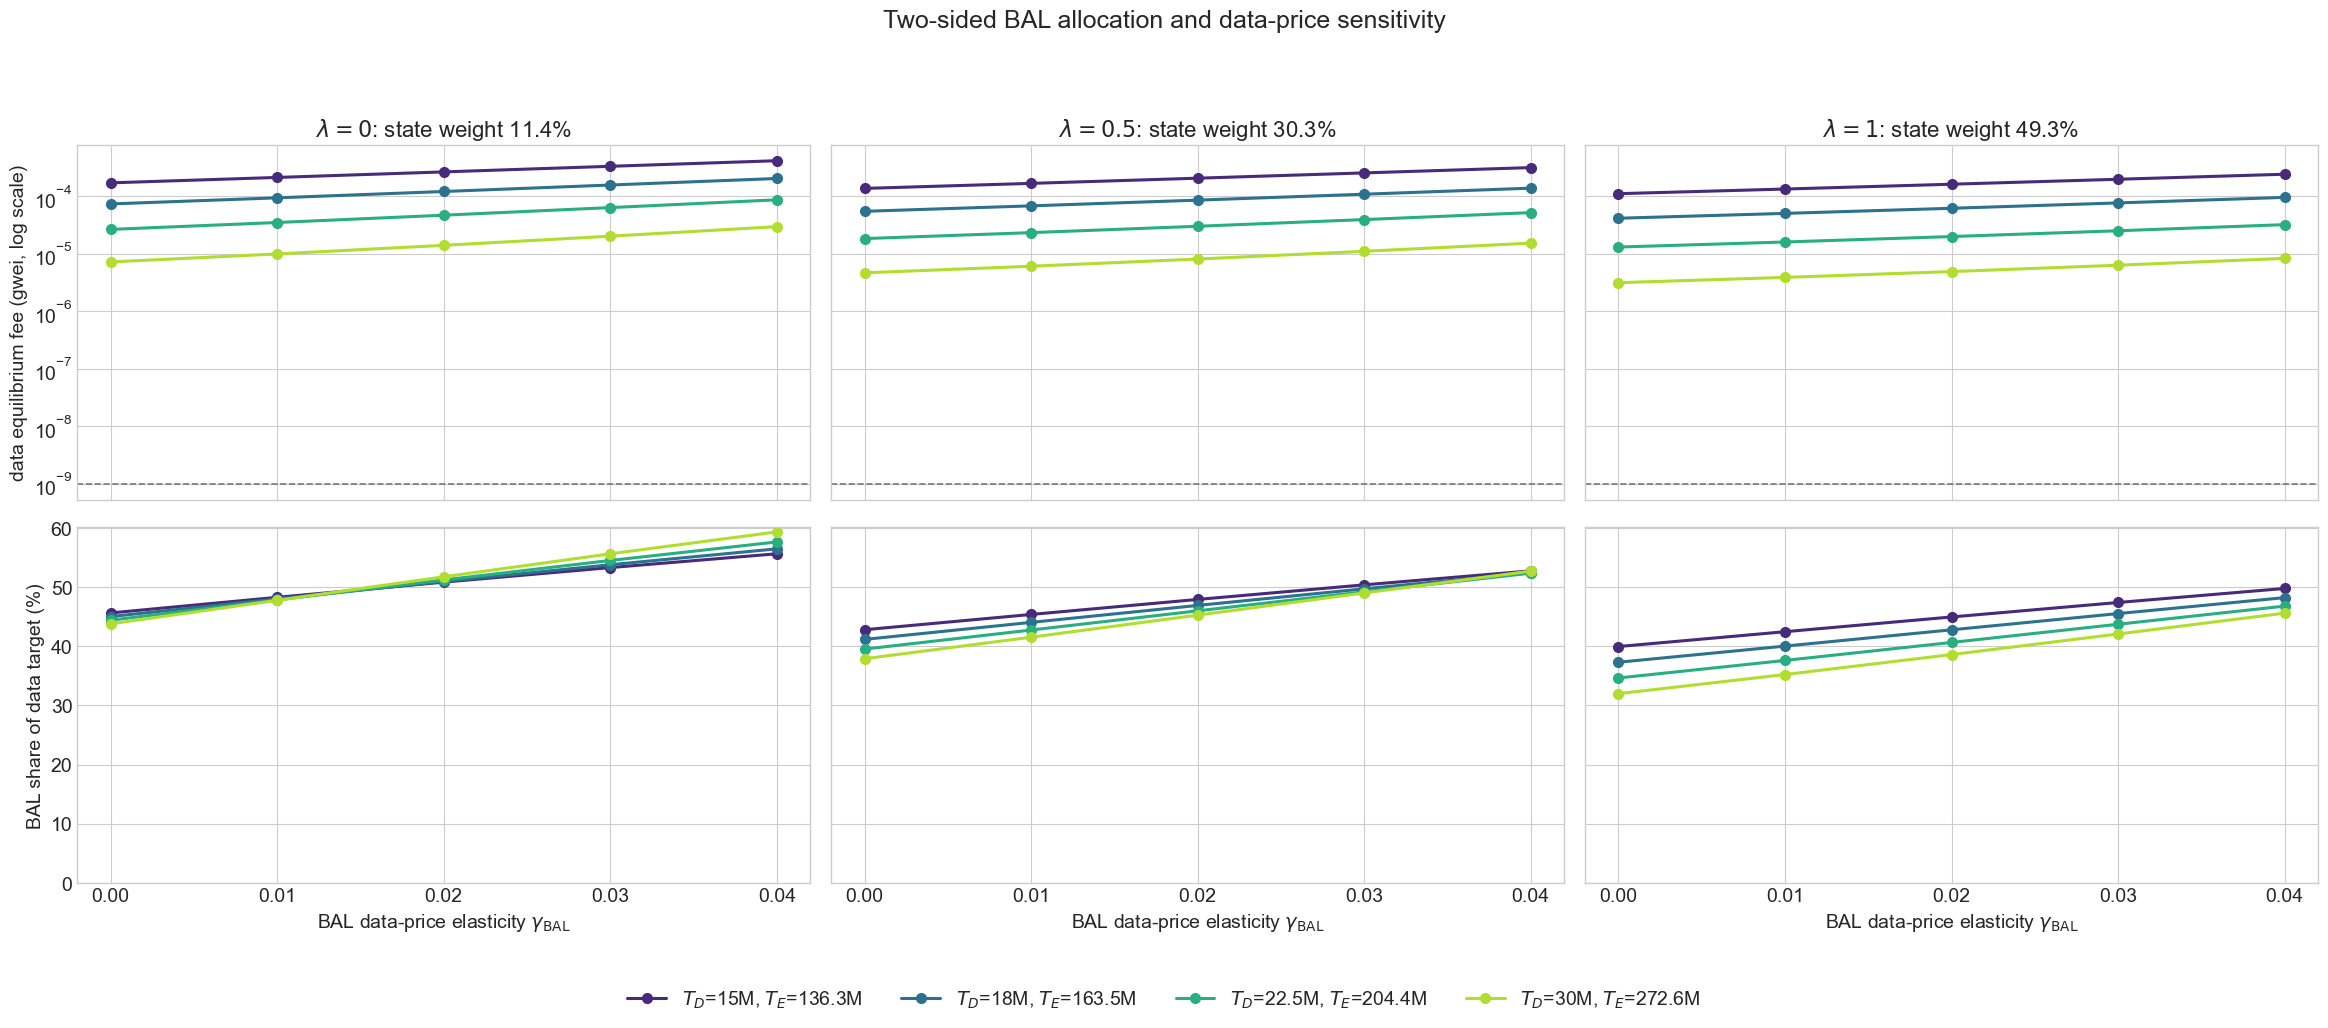

bal_price_elasticity_gamma                                                   0.000000  \
data_gas_target execution_gas_target bal_coproduced_state_allocation_lambda             
15000000        136283592            0.000000                                0.000172   
                                     0.500000                                0.000138   
                                     1.000000                                0.000111   
18000000        163540310            0.000000                                0.000074   
                                     0.500000                                0.000055   
                                     1.000000                                0.000042   
22500000        204425388            0.000000                                0.000027   
                                     0.500000                                0.000018   
                                     1.000000                                0.000013   
30000000        272567184            0.000000                                0.000007   
                                     0.500000                                0.000005   
                                     1.000000                                0.000003   

bal_price_elasticity_gamma                                                   0.010000  \
data_gas_target execution_gas_target bal_coproduced_state_allocation_lambda             
15000000        136283592            0.000000                                0.000213   
                                     0.500000                                0.000168   
                                     1.000000                                0.000134   
18000000        163540310            0.000000                                0.000094   
                                     0.500000                                0.000068   
                                     1.000000                                0.000051   
22500000        204425388            0.000000                                0.000035   
                                     0.500000                                0.000023   
                                     1.000000                                0.000016   
30000000        272567184            0.000000                                0.000010   
                                     0.500000                                0.000006   
                                     1.000000                                0.000004   

bal_price_elasticity_gamma                                                   0.020000  \
data_gas_target execution_gas_target bal_coproduced_state_allocation_lambda             
15000000        136283592            0.000000                                0.000266   
                                     0.500000                                0.000207   
                                     1.000000                                0.000163   
18000000        163540310            0.000000                                0.000122   
                                     0.500000                                0.000086   
                                     1.000000                                0.000062   
22500000        204425388            0.000000                                0.000047   
                                     0.500000                                0.000030   
                                     1.000000                                0.000020   
30000000        272567184            0.000000                                0.000014   
                                     0.500000                                0.000008   
                                     1.000000                                0.000005   

bal_price_elasticity_gamma                                                   0.030000  \
data_gas_target execution_gas_target bal_coproduced_state_allocation_lambda             
15000000        136283592            0.000000                                0.00

,data_gas_target,execution_gas_target,bal_coproduced_state_allocation_lambda,bal_price_elasticity_gamma,execution_equilibrium_fee_wei,equilibrium_base_fee_gwei,state_equilibrium_fee_gwei,bal_data_gas_at_equilibrium,bal_share_of_data_target,protocol_base_fee_wei
600,15000000,136283592,0.000000,0.000000,"1,416.558508",0.000172,0.001184,"6,846,665.828622",0.456444,171734
604,15000000,136283592,0.000000,0.040000,"1,416.558508",0.000417,0.001184,"8,347,672.733357",0.556512,416788
605,15000000,136283592,0.500000,0.000000,"1,416.558508",0.000138,0.001184,"6,420,376.291732",0.428025,137533
609,15000000,136283592,0.500000,0.040000,"1,416.558508",0.000317,0.001184,"7,914,482.210248",0.527632,316608
610,15000000,136283592,1.000000,0.000000,"1,416.558508",0.000111,0.001184,"5,994,086.754841",0.399606,111336
614,15000000,136283592,1.000000,0.040000,"1,416.558508",0.000243,0.001184,"7,468,098.276748",0.497873,242604
615,18000000,163540310,0.000000,0.000000,314.562013,0.000074,0.001184,"8,105,427.050842",0.450302,73882
619,18000000,163540310,0.000000,0.040000,314.562013,0.000205,0.001184,"10,167,714.790814",0.564873,204591
620,18000000,163540310,0.500000,0.000000,314.562013,0.000055,0.001184,"7,410,078.027181",0.411671,54954
624,18000000,163540310,0.500000,0.040000,314.562013,0.000139,0.001184,"9,440,438.257914",0.524469,138943


In [5]:
lambda_weight_table = pd.DataFrame([
    {
        "lambda": lambda_bal,
        "state_weight": (
            BAL_DIRECT_STATE_WEIGHT
            + lambda_bal * BAL_COPRODUCED_RUNTIME_WEIGHT
        ),
        "execution_access_weight": (
            BAL_NONSTATE_RUNTIME_WEIGHT
            + (1 - lambda_bal) * BAL_COPRODUCED_RUNTIME_WEIGHT
        ),
    }
    for lambda_bal in BAL_LAMBDA_SENSITIVITY
])
display(lambda_weight_table)

paired_scenario_order = (
    paired_bal_sensitivity[[
        "scenario", "execution_gas_target", "data_gas_target"
    ]]
    .drop_duplicates()
    .sort_values("data_gas_target")
)
scenario_colors = dict(zip(
    paired_scenario_order["scenario"],
    plt.cm.viridis(np.linspace(0.12, 0.88, len(paired_scenario_order))),
))

fig, axes = plt.subplots(
    2, 3, figsize=(23.5, 10.5), sharex="col", sharey="row"
)
for column, lambda_bal in enumerate(BAL_LAMBDA_SENSITIVITY):
    lambda_rows = paired_bal_sensitivity[
        paired_bal_sensitivity[
            "bal_coproduced_state_allocation_lambda"
        ].eq(lambda_bal)
    ]
    for scenario_row in paired_scenario_order.itertuples(index=False):
        subset = lambda_rows[
            lambda_rows["scenario"].eq(scenario_row.scenario)
        ].sort_values("bal_price_elasticity_gamma")
        label = (
            f"$T_D$={scenario_row.data_gas_target / 1e6:g}M, "
            f"$T_E$={scenario_row.execution_gas_target / 1e6:.1f}M"
        )
        axes[0, column].plot(
            subset["bal_price_elasticity_gamma"],
            subset["equilibrium_base_fee_gwei"],
            marker="o", linewidth=2.2, markersize=7,
            color=scenario_colors[scenario_row.scenario], label=label,
        )
        axes[1, column].plot(
            subset["bal_price_elasticity_gamma"],
            100 * subset["bal_share_of_data_target"],
            marker="o", linewidth=2.2, markersize=7,
            color=scenario_colors[scenario_row.scenario], label=label,
        )

    state_weight = lambda_weight_table.loc[
        lambda_weight_table["lambda"].eq(lambda_bal), "state_weight"
    ].iloc[0]
    axes[0, column].set_title(
        f"$\\lambda={lambda_bal:g}$: state weight {100 * state_weight:.1f}%"
    )
    axes[0, column].set_yscale("log")
    axes[0, column].axhline(
        1 / GWEI, color="#777777", linestyle="--", linewidth=1.2,
    )
    axes[1, column].set_xlabel(
        r"BAL data-price elasticity $\gamma_{\mathrm{BAL}}$"
    )
    axes[1, column].set_xticks(BAL_GAMMA_SENSITIVITY)
    axes[1, column].set_ylim(bottom=0)

axes[0, 0].set_ylabel("data equilibrium fee (gwei, log scale)")
axes[1, 0].set_ylabel("BAL share of data target (%)")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.01),
    ncol=4, frameon=False, fontsize=14,
)
fig.suptitle("Two-sided BAL allocation and data-price sensitivity", y=0.98)
fig.tight_layout(rect=(0, 0.08, 1, 0.94))
fig.savefig(BAL_SENSITIVITY_PLOT, dpi=180, bbox_inches="tight")
plt.show()

paired_fee_grid = paired_bal_sensitivity.pivot_table(
    index=[
        "data_gas_target", "execution_gas_target",
        "bal_coproduced_state_allocation_lambda",
    ],
    columns="bal_price_elasticity_gamma",
    values="equilibrium_base_fee_gwei",
).sort_index()
display(paired_fee_grid)

paired_endpoints = paired_headline[
    paired_headline["bal_price_elasticity_gamma"].isin([0.0, 0.04])
][[
    "data_gas_target", "execution_gas_target",
    "bal_coproduced_state_allocation_lambda",
    "bal_price_elasticity_gamma",
    "execution_equilibrium_fee_wei",
    "equilibrium_base_fee_gwei",
    "state_equilibrium_fee_gwei",
    "bal_data_gas_at_equilibrium",
    "bal_share_of_data_target",
    "protocol_base_fee_wei",
]].sort_values([
    "data_gas_target",
    "bal_coproduced_state_allocation_lambda",
    "bal_price_elasticity_gamma",
])
display(paired_endpoints)


## Elasticity-window sensitivity

The exported window file evaluates all 44 capacity scenarios across the 21-, 35-, 60-, and 75-day
elasticity estimates. The table below summarizes its paired subset. The calculation remains
target-conditioned: parent BAL uses the requested execution target even
when a long-window execution curve cannot reach that target at the one-wei minimum. The
`parent_execution_target_reachable` field in the exported window CSV identifies those cases.
A dynamic replay should instead feed realized execution usage into BAL generation.


In [6]:
paired_window_sensitivity = window_sensitivity[
    window_sensitivity["empirically_matched"]
].copy()
window_summary = (
    paired_window_sensitivity[
        paired_window_sensitivity["bal_price_elasticity_gamma"].isin([0.0, 0.02, 0.04])
    ]
    .groupby([
        "data_gas_target", "execution_gas_target",
        "bal_coproduced_state_allocation_lambda",
        "bal_price_elasticity_gamma",
    ])
    .agg(
        fee_min_gwei=("equilibrium_base_fee_gwei", "min"),
        fee_max_gwei=("equilibrium_base_fee_gwei", "max"),
        bal_share_min=("bal_share_of_data_target", "min"),
        bal_share_max=("bal_share_of_data_target", "max"),
        all_parent_execution_targets_reachable=(
            "parent_execution_target_reachable", "all"
        ),
    )
    .reset_index()
)
display(window_summary)

headline_ranges = (
    paired_headline
    .groupby([
        "bal_coproduced_state_allocation_lambda",
        "bal_price_elasticity_gamma",
    ])
    .agg(
        data_fee_min_gwei=("equilibrium_base_fee_gwei", "min"),
        data_fee_max_gwei=("equilibrium_base_fee_gwei", "max"),
        bal_share_min=("bal_share_of_data_target", "min"),
        bal_share_max=("bal_share_of_data_target", "max"),
    )
    .reset_index()
)
display(headline_ranges)


,data_gas_target,execution_gas_target,bal_coproduced_state_allocation_lambda,bal_price_elasticity_gamma,fee_min_gwei,fee_max_gwei,bal_share_min,bal_share_max,all_parent_execution_targets_reachable
0,15000000,136283592,0.000000,0.000000,0.000076,0.000172,0.456444,0.456444,True
1,15000000,136283592,0.000000,0.020000,0.000135,0.000266,0.508533,0.515521,True
2,15000000,136283592,0.000000,0.040000,0.000240,0.000417,0.556512,0.568900,True
3,15000000,136283592,0.500000,0.000000,0.000059,0.000138,0.428025,0.428025,True
4,15000000,136283592,0.500000,0.020000,0.000101,0.000207,0.479280,0.486248,True
5,15000000,136283592,0.500000,0.040000,0.000175,0.000317,0.527632,0.540323,True
6,15000000,136283592,1.000000,0.000000,0.000046,0.000111,0.399606,0.399606,True
7,15000000,136283592,1.000000,0.020000,0.000076,0.000163,0.449623,0.456507,True
8,15000000,136283592,1.000000,0.040000,0.000128,0.000243,0.497873,0.510736,True
9,18000000,163540310,0.000000,0.000000,0.000029,0.000074,0.450302,0.450302,False


,bal_coproduced_state_allocation_lambda,bal_price_elasticity_gamma,data_fee_min_gwei,data_fee_max_gwei,bal_share_min,bal_share_max
0,0.000000,0.000000,0.000007,0.000172,0.438016,0.456444
1,0.000000,0.010000,0.000010,0.000213,0.477774,0.482856
2,0.000000,0.020000,0.000014,0.000266,0.508533,0.517554
3,0.000000,0.030000,0.000020,0.000333,0.533169,0.556440
4,0.000000,0.040000,0.000030,0.000417,0.556512,0.593538
5,0.500000,0.000000,0.000005,0.000138,0.378963,0.428025
6,0.500000,0.010000,0.000006,0.000168,0.415398,0.453869
7,0.500000,0.020000,0.000008,0.000207,0.452726,0.479280
8,0.500000,0.030000,0.000011,0.000256,0.490254,0.503956
9,0.500000,0.040000,0.000015,0.000317,0.523747,0.527632


## Interpretation

- At $\gamma_{\mathrm{BAL}}=0$, this notebook exactly reproduces notebook 2.0 with
  $\beta_{\mathrm{BAL}}=0$ for every value of $\lambda$ in the grid.
- Positive $\gamma_{\mathrm{BAL}}$ removes the high-fee feasibility boundary because modeled BAL
  tends to zero as the data fee grows. The one-wei protocol minimum remains a separate possible
  lower-fee constraint.
- In the paired scenarios, $b_{\mathrm{data}}^*<b_{\mathrm{data}}^0$. A larger two-sided
  elasticity therefore expands BAL, raises BAL's share of the data target, and raises the
  target-clearing data fee.
- The range $\gamma_{\mathrm{BAL}}=0.02$--$0.03$ is the main sensitivity region motivated by the
  static-data cost share of BAL-carrying transactions. The $0.04$ case is a functional-form
  stress test rather than an empirical estimate.
- The reserve price is excluded. These are reserve-free target-clearing equilibria.
